# Overfitting ( 오버 피팅 )

- 머신러닝에서 모델이 훈련 데이터에 지나치게 잘 맞춰저 있어, 새로운 또는 보이지 않는 데이터에 대해 일반화 하는 능력이 떨어지는 현상 
- 모델이 훈련 데이터 뿐만아니라 노이즈까지 학습해버려, 실제 세계의 복잡성과 변동성을 반영하는데 실패하는 상태 
- 모델이 너무 복잡하거나 훈련 데이터가 너무 적을 때 자주 발생 

## Cross Validation ( 교차 검증 )

### 검증 데이터 

- 머신러닝 모델을 개발할 때 모델의 성능을 평가하고 하이퍼파라미터를 조정하는데 사용되는 데이터 세트 
- Training, Validation data, Test data 로 나누게 됨. 

#### K-fold Cross_validation ( K 겹 교차 검증 )

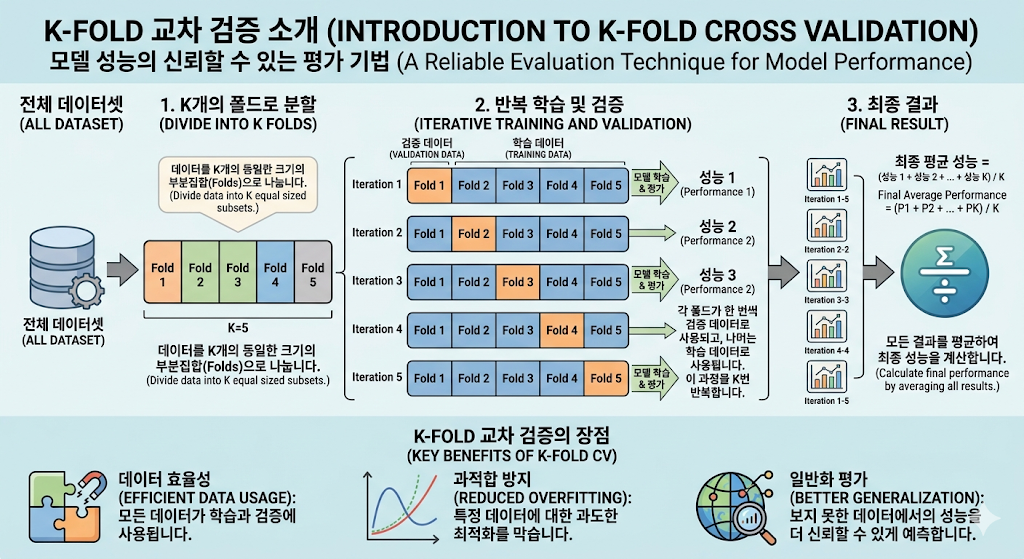

- 데이터를 K개의 동일한 크기의 부분집합( Fold )로 나눠 한번씩 돌아가면서 검증 데이터로 사용 


## 장점

- 데이터 활용 극대화 
- 모델의 일반화 능력 평가 
- 오버 피팅 감소 
- 하이퍼파라미터 튜닝의 용이성 

In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

# iris 데이터셋 로드
iris = load_iris()
X, y = iris.data, iris.target

# KFold 분할기 인스턴스 생성 (5-겹 교차 검증)
kf = KFold(n_splits=5, shuffle=True, random_state=42)  
# n_splits : 폴드의 개수(K)를 정의, 교차 검증에서 생성할 폴드의 수를 지정, 기본값은 5
# shuffle: boolean 값으로 각 폴드를 생성하기 전에 데이터를 섞을지 여부 결정, 기본값을 False
# random_state: shuffle = True 로 설정 된 경우 데이터 섞기의 랜덤성을 제어하기 위한 시드 값, 기본 값은 None

# 정확도 점수를 저장할 리스트
accuracy_scores = []

# KFold로 데이터를 분할
for train_index, test_index in kf.split(X):
    # 분할된 훈련 및 테스트 데이터 생성
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 모델 생성 및 훈련
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # 예측 및 정확도 계산
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    # 정확도 점수를 리스트에 추가
    accuracy_scores.append(accuracy)

# 각 폴드에서의 정확도 출력
print("각 폴드에서의 정확도:", accuracy_scores)

# 평균 정확도 계산 및 출력
print("평균 정확도:", np.mean(accuracy_scores))

각 폴드에서의 정확도: [1.0, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9666666666666667]
평균 정확도: 0.9600000000000002


## 교차 검증 ( Cross-validation )

- 교차 검증 
- sklearn.model_selection 의 `cross_val_score`를 사용

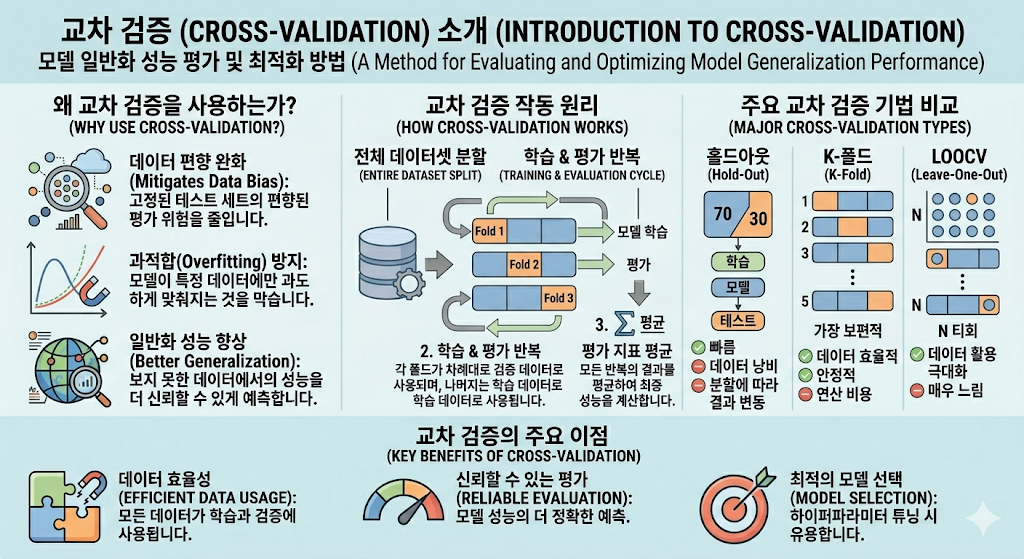

In [3]:
# iris 데이터셋 로드
X, y = iris.data, iris.target

# 모델 초기화
model = RandomForestClassifier()

print('X 데이터 크기:', X.size)
print('y 데이터 크기:', y.size)
print('모델 :', model)

from sklearn.model_selection import cross_val_score

# 교차 검증 실행
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy') # model: 평가할 모델, X: 특성 데이터, y: 타겟 데이터, cv: 교차 검증 폴드 수, scoring: 평가 지표

# 결과 출력
print("교차 검증 정확도 점수:", scores)
print("평균 정확도:", scores.mean())

X 데이터 크기: 600
y 데이터 크기: 150
모델 : RandomForestClassifier()
교차 검증 정확도 점수: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
평균 정확도: 0.96


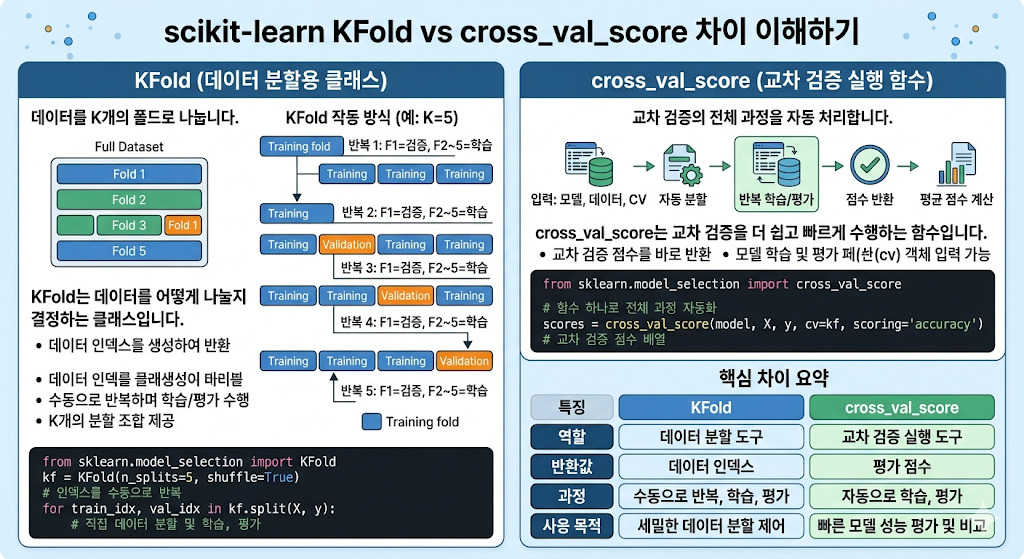

`cross_val_score` 함수의 `scoring` 매개변수는 **모델의 성능을 어떤 지표(Metric)로 평가할 것인지**를 결정합니다.

scikit-learn은 다양한 평가 지표를 문자열 형태로 제공하며, 풀고자 하는 문제(분류인지 회귀인지)에 따라 알맞은 지표를 선택해야 합니다.

가장 자주 사용되는 주요 `scoring` 값들을 문제 유형별로 나누어 설명해 드리겠습니다.

---

### 1. 분류 (Classification) 모델을 위한 평가 지표

분류 문제에서는 모델이 클래스를 얼마나 잘 맞추었는지 평가합니다.

* **`'accuracy'` (정확도):** 전체 예측 데이터 중 올바르게 예측한 비율입니다. 데이터의 클래스 비율이 균형 잡혀 있을 때 주로 사용합니다. (분류 모델의 기본값)
* **`'precision'` (정밀도):** 모델이 'Positive'라고 예측한 것 중 실제로 'Positive'인 비율입니다. (예: 스팸 메일 분류에서 정상 메일을 스팸으로 잘못 거르면 안 될 때 중요)
* **`'recall'` (재현율):** 실제 'Positive'인 것 중 모델이 'Positive'라고 올바르게 예측한 비율입니다. 민감도(Sensitivity)라고도 합니다. (예: 암 환자 진단처럼 실제 암 환자를 놓치면 안 될 때 중요)
* **`'f1'` (F1 스코어):** 정밀도와 재현율의 조화 평균입니다. 데이터 클래스가 불균형할 때 성능을 정확하게 평가하기 좋습니다.
* **`'roc_auc'` (ROC AUC 스코어):** ROC 곡선 아래의 면적을 의미하며, 이진 분류에서 모델의 예측 성능을 임계값에 상관없이 종합적으로 평가할 때 유용합니다.

> **참고:** 다중 클래스(Multi-class) 분류인 경우, `f1_macro`, `f1_micro`, `precision_macro` 등 평균 계산 방식을 지정하는 접미사를 붙여 사용해야 합니다.

### 2. 회귀 (Regression) 모델을 위한 평가 지표

회귀 문제에서는 모델의 예측값과 실제 정답 사이의 오차(Error)가 얼마나 적은지를 평가합니다.

* **`'r2'` (결정계수):** 예측 모델이 실제 데이터를 얼마나 잘 설명하는지 나타내는 지표입니다. 1에 가까울수록 예측력이 높음을 의미합니다. (회귀 모델의 기본값)
* **`'neg_mean_squared_error'` (Negative MSE):** 실제값과 예측값의 차이를 제곱하여 평균 낸 값에 음수(-)를 붙인 것입니다.
* **`'neg_root_mean_squared_error'` (Negative RMSE):** MSE에 루트를 씌운 값에 음수(-)를 붙인 것입니다. 직관적인 오차 크기를 확인할 수 있습니다.
* **`'neg_mean_absolute_error'` (Negative MAE):** 실제값과 예측값의 차이의 절대값을 평균 낸 값에 음수(-)를 붙인 것입니다. 이상치(Outlier)에 덜 민감합니다.

---

### 💡 왜 회귀 지표 앞에는 `neg_`(Negative)가 붙을까요?

scikit-learn의 교차 검증 및 그리드 서치(GridSearch) 등은 "점수(Score)가 클수록 더 좋은 모델"이라는 일관된 규칙을 따릅니다.

* 정확도(`accuracy`)나 R²(`r2`)는 값이 클수록 좋은 것이 맞습니다.
* 하지만 오차(MSE, MAE 등)는 **작을수록 좋은 모델**입니다.

따라서 일관된 규칙("큰 값이 좋다")을 유지하기 위해, 원래 오차 값에 음수(-1)를 곱해 반환하는 것입니다. 예를 들어 오차가 10, 5일 때 음수를 붙이면 -10, -5가 되며, 이 중 더 큰 값인 -5를 낸 모델이 더 훌륭한 모델로 평가됩니다. 나중에 실제 오차 값을 확인할 때는 다시 음수를 곱해주어야 합니다.

평가 지표(`scoring`)를 선택할 때는 '우리 데이터가 어떻게 생겼는지'와 '이 모델로 해결하려는 비즈니스 문제가 무엇인지'에 따라 기준이 완전히 달라집니다.

실무에서 각 지표를 언제, 왜 자주 사용하는지 상황별로 이해하기 쉽게 정리해 드립니다.

---

## 1. 분류 (Classification) 지표: "어떤 실수가 더 치명적인가?"

분류 문제에서는 정답을 맞히는 것도 중요하지만, '틀렸을 때 어떤 종류의 에러가 발생하는지'가 핵심입니다.

### 🎯 `'accuracy'` (정확도)

* **언제 자주 쓰나요?** 데이터의 정답 클래스 비율이 50:50으로 **균형 잡혀 있을 때** 가장 기본적으로 사용합니다.
* **이럴 땐 쓰면 안 돼요!** 데이터가 극도로 불균형할 때(예: 정상 99%, 불량 1%). 모델이 무조건 "전부 정상입니다"라고만 찍어도 정확도가 99%가 나오기 때문에 성능을 착각하게 만듭니다.

### 🚨 `'recall'` (재현율)

* **언제 자주 쓰나요?** **실제 양성(True)을 놓치는 것(미탐)이 치명적인 결과를 초래할 때** 사용합니다.
* **대표적인 예시:**
* **암 환자 진단:** 실제 암 환자를 정상으로 오진하면 생명이 위험합니다. (정상인을 암으로 오진하는 한이 있더라도 암 환자는 다 찾아내야 함)
* **신용카드 사기 탐지:** 사기 거래를 놓치면 금전적 손실이 발생합니다.
* **공장 불량품 검출:** 불량품이 고객에게 배송되는 것을 막아야 합니다.



### 🛡️ `'precision'` (정밀도)

* **언제 자주 쓰나요?** **가짜 양성(False Positive), 즉 오람(잘못 울린 알람)이 발생하면 안 될 때** 사용합니다. 모델이 '맞다'고 한 것이 정말로 맞아야만 하는 상황입니다.
* **대표적인 예시:**
* **스팸 메일 필터링:** 중요한 업무 메일을 스팸으로 잘못 분류해서 삭제해버리면 큰일 납니다. (스팸을 좀 놓치더라도, 정상 메일은 건드리면 안 됨)
* **무죄 추정의 원칙:** 억울한 사람을 범죄자로 만들면 안 되는 법적 판단 모델.



### ⚖️ `'f1'` (F1 스코어)

* **언제 자주 쓰나요?** 데이터가 불균형한데, **정밀도와 재현율 중 어느 하나만 포기하기 어려울 때** 종합적인 성능을 보기 위해 가장 많이 사용합니다. 실무에서 불균형 데이터를 다룰 때 가장 사랑받는 지표 중 하나입니다.

### 📈 `'roc_auc'`

* **언제 자주 쓰나요?** 모델이 예측하는 '확률값' 자체의 품질을 평가할 때 씁니다. 임계값(Threshold)을 어떻게 설정하든 **전반적으로 얼마나 클래스를 잘 구별하는지** 비교하고 싶을 때, 여러 모델의 성능을 줄 세우기 할 때 매우 유용합니다.

---

## 2. 회귀 (Regression) 지표: "오차를 어떻게 바라볼 것인가?"

회귀 문제에서는 예측값과 실제값의 차이(오차)를 다루는데, 데이터에 튀는 값(이상치)이 있는지, 오차의 단위를 어떻게 해석할지에 따라 선택합니다.

### 📏 `'neg_root_mean_squared_error'` (Negative RMSE)

* **언제 자주 쓰나요?** 회귀 모델 평가에서 **가장 보편적으로 많이 쓰이는 지표**입니다. 오차를 제곱하기 때문에 **큰 오차를 내는 모델에게 강한 페널티**를 줍니다.
* **대표적인 예시:** 집값 예측, 매출 예측. (오차가 10만 원 나는 것보다, 100만 원 나는 것이 기하급수적으로 더 나쁘다고 평가하고 싶을 때)

### 🛡️ `'neg_mean_absolute_error'` (Negative MAE)

* **언제 자주 쓰나요?** 데이터에 **비정상적인 이상치(Outlier)가 많을 때** 사용합니다. RMSE는 오차를 제곱해서 이상치에 너무 민감하게 반응하지만, MAE는 절대값만 씌우므로 이상치에 덜 휘둘립니다.
* **장점:** "우리 모델은 평균적으로 5,000원 정도 오차가 납니다"처럼 비즈니스 부서에 직관적으로 설명하기 좋습니다.

### 📊 `'r2'` (결정계수)

* **언제 자주 쓰나요?** 오차의 절대적인 크기(원, 달러, kg 등)를 떠나서, "그래서 이 모델이 전체 데이터의 변동성을 몇 %나 설명하는데?"라는 질문에 답해야 할 때 씁니다.
* **장점:** 0과 1 사이의 값으로 나오기 때문에(가끔 음수도 나오지만), 서로 다른 데이터셋을 학습한 모델들끼리 성능을 대략적으로 비교하거나, 비개발 직군에게 모델의 '설명력'을 보고할 때 유용합니다.